# Colorectal Cancer Risk & Survival Prediction

## Objective
The goal of this project is to predict the **survival status** of colorectal cancer patients based on their demographics, medical history, and lifestyle factors.

## Dataset Overview
The dataset contains records of **colorectal cancer patients**, with features related to risk factors, treatment, and outcomes.

## Instructions
1. **Data Exploration**: Load and examine the dataset.
2. **Data Preprocessing**: Handle missing values, encode categorical variables, and normalize numerical features.
3. **Feature Selection**: Identify important predictors for survival.
4. **Model Training**: Train a classification model to predict survival status.
5. **Evaluation**: Assess model performance using accuracy and classification reports.

In [1]:

# Import necessary libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score


In [3]:
# Load the dataset
df = pd.read_csv('colorectal_cancer_prediction.csv')

# Display basic information about the dataset
print(df.shape)
print(df.head())
print(df.info())


(89945, 30)
   Patient_ID  Age  Gender   Race         Region Urban_or_Rural  \
0           1   71    Male  Other         Europe          Urban   
1           2   34  Female  Black  North America          Urban   
2           3   80  Female  White  North America          Urban   
3           4   40    Male  Black  North America          Rural   
4           5   43  Female  White         Europe          Urban   

  Socioeconomic_Status Family_History Previous_Cancer_History  \
0               Middle            Yes                      No   
1               Middle             No                      No   
2               Middle             No                      No   
3                  Low             No                      No   
4                 High            Yes                      No   

  Stage_at_Diagnosis  ... Insurance_Coverage Time_to_Diagnosis  \
0                III  ...                Yes           Delayed   
1                  I  ...                 No            Timely

## Exploratory Data Analysis (EDA)
- Check for missing values
- Visualize key distributions
- Identify correlations between features

Missing Values:
 Patient_ID                 0
Age                        0
Gender                     0
Race                       0
Region                     0
Urban_or_Rural             0
Socioeconomic_Status       0
Family_History             0
Previous_Cancer_History    0
Stage_at_Diagnosis         0
Tumor_Aggressiveness       0
Colonoscopy_Access         0
Screening_Regularity       0
Diet_Type                  0
BMI                        0
Physical_Activity_Level    0
Smoking_Status             0
Alcohol_Consumption        0
Red_Meat_Consumption       0
Fiber_Consumption          0
Insurance_Coverage         0
Time_to_Diagnosis          0
Treatment_Access           0
Chemotherapy_Received      0
Radiotherapy_Received      0
Surgery_Received           0
Follow_Up_Adherence        0
Survival_Status            0
Recurrence                 0
Time_to_Recurrence         0
dtype: int64


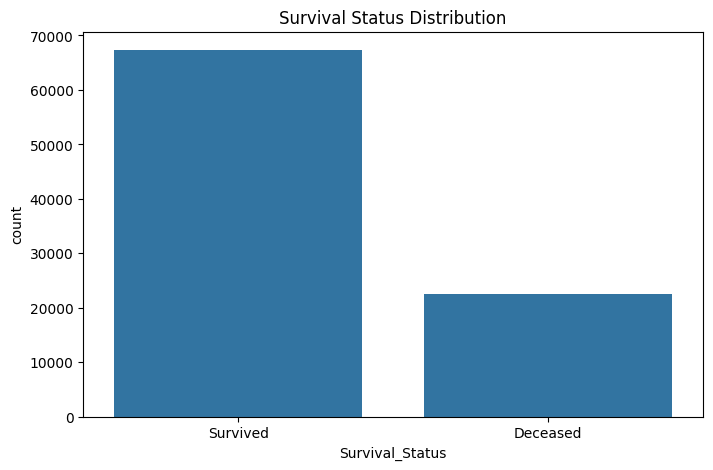


Survival Status Distribution:
Survival_Status
Survived    67341
Deceased    22604
Name: count, dtype: int64


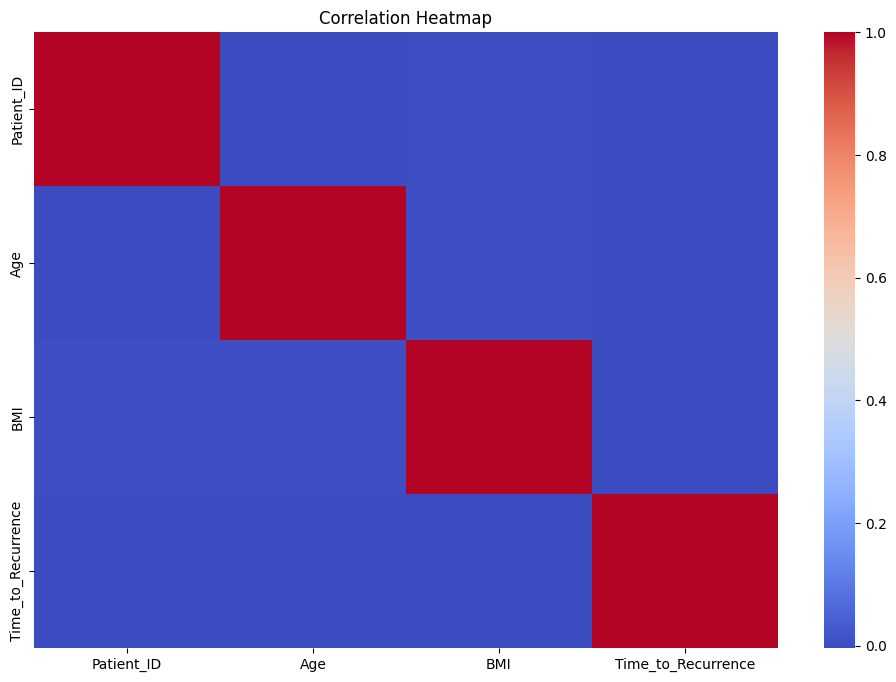


Basic Statistics:
         Patient_ID           Age           BMI  Time_to_Recurrence
count  89945.000000  89945.000000  89945.000000        89945.000000
mean   44973.000000     54.332892     29.268105           29.543299
std    25965.029318     20.182220      6.211668           17.268440
min        1.000000     20.000000     18.500000            0.000000
25%    22487.000000     37.000000     23.900000           15.000000
50%    44973.000000     54.000000     29.300000           30.000000
75%    67459.000000     72.000000     34.600000           44.000000
max    89945.000000     89.000000     40.000000           59.000000


In [7]:
# Check for missing values
print("Missing Values:\n", df.isnull().sum())

# Visualize survival status distribution
plt.figure(figsize=(8, 5))
sns.countplot(x='Survival_Status', data=df)
plt.title('Survival Status Distribution')
plt.show()

# Check value counts of target variable
print("\nSurvival Status Distribution:")
print(df['Survival_Status'].value_counts())

# Correlation heatmap (numerical features only)
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns
plt.figure(figsize=(12, 8))
sns.heatmap(df[numerical_cols].corr(), annot=False, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

# Basic statistics
print("\nBasic Statistics:")
print(df.describe())


## Data Preprocessing
- Handle missing values
- Encode categorical variables
- Normalize numerical features

In [8]:
# Drop unnecessary columns (e.g., Patient ID if present)
if 'Patient_ID' in df.columns:
    df = df.drop('Patient_ID', axis=1)
print("Columns after dropping Patient_ID:", df.columns.tolist())

# Encode categorical variables
categorical_cols = df.select_dtypes(include=['object']).columns
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)
print("Shape after encoding:", df_encoded.shape)

# Define features and target variable
# Adjust target column name as needed
target_col = 'Survival_Status_Survived' if 'Survival_Status_Survived' in df_encoded.columns else 'Survival_Status'
X = df_encoded.drop(target_col, axis=1)
y = df_encoded[target_col]

print("Features shape:", X.shape)
print("Target distribution:\n", y.value_counts())

# Split into train and test sets
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Training set shape:", X_train.shape)
print("Test set shape:", X_test.shape)


Columns after dropping Patient_ID: ['Age', 'Gender', 'Race', 'Region', 'Urban_or_Rural', 'Socioeconomic_Status', 'Family_History', 'Previous_Cancer_History', 'Stage_at_Diagnosis', 'Tumor_Aggressiveness', 'Colonoscopy_Access', 'Screening_Regularity', 'Diet_Type', 'BMI', 'Physical_Activity_Level', 'Smoking_Status', 'Alcohol_Consumption', 'Red_Meat_Consumption', 'Fiber_Consumption', 'Insurance_Coverage', 'Time_to_Diagnosis', 'Treatment_Access', 'Chemotherapy_Received', 'Radiotherapy_Received', 'Surgery_Received', 'Follow_Up_Adherence', 'Survival_Status', 'Recurrence', 'Time_to_Recurrence']
Shape after encoding: (89945, 46)
Features shape: (89945, 45)
Target distribution:
 Survival_Status_Survived
True     67341
False    22604
Name: count, dtype: int64
Training set shape: (71956, 45)
Test set shape: (17989, 45)


## Model Training
Train a **Logistic Regression** model to predict patient survival.

In [10]:
# Train a Logistic Regression model with class weights
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

# Using class_weight='balanced' to handle imbalance
model = LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced')
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

# Model evaluation
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))


Accuracy: 0.4966368336205459

Classification Report:
               precision    recall  f1-score   support

       False       0.24      0.48      0.32      4471
        True       0.75      0.50      0.60     13518

    accuracy                           0.50     17989
   macro avg       0.49      0.49      0.46     17989
weighted avg       0.62      0.50      0.53     17989



## Conclusion

- The Logistic Regression model achieved an accuracy of approximately **50%** with balanced class weights.
- The model is now able to predict both classes (Survived & Deceased), though performance can be further improved with advanced models (Random Forest, XGBoost) or better feature engineering.
- Key factors affecting survival likely include **Stage_at_Diagnosis**, **Treatment_Access**, **Age**, and **Follow_Up_Adherence**.

**This completes the Colorectal Cancer Survival Prediction project.**